In [1]:
import ouroboros as obo
import anndata as ad
import pandas as pd
from scphere.model.vae import SCPHERE
from scphere.util.trainer import Trainer
import numpy as np
import tensorflow as tf
from kneed import KneeLocator
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt

In [2]:
test_adata = ad.read_h5ad('/projects/steiflab/scratch/mtong/ovarian_cancer/ovarian_immune_rawcounts.h5ad')

In [3]:
discrete = ad.read_h5ad('/projects/steiflab/scratch/hmacdonald/total_RNA_scratch/wechter_scratch/starsolo_counts/h5ads/discrete.h5ad')
discrete

AnnData object with n_obs × n_vars = 2979 × 60649
    obs: 'rep', 'doublet_score', 'doublet_class', 'treatment', 'n_counts', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    layers: 'logged_counts', 'raw_counts', 'scaled_logged_counts', 'spliced', 'unspliced'

In [54]:
import random 
feature_set = pd.read_csv('/home/glchang/scratch/Ouroboros/ouroboros/data/SHAP_feature_set.csv')
feature_set = feature_set.feature_set.tolist()

# Choose 5 unique items to remove
to_remove = random.sample(feature_set, 10)

# Remove them from the list
for item in to_remove:
    feature_set.remove(item)

new_feature_set = feature_set

matrix = pd.read_csv("/home/glchang/scratch/Ouroboros/ouroboros/data/train_matrix.csv")
meta = pd.read_csv('/home/glchang/scratch/Ouroboros/ouroboros/data/train_meta.csv')
meta.set_index('Unnamed: 0', inplace = True)

matrix = matrix.loc[:, new_feature_set]
in_order_feature_set = matrix.columns.tolist()
matrix = matrix.values

map_dict = {}
for i, val in enumerate(meta['library'].unique()):
    map_dict[val] = i
batch = meta['library'].map(map_dict).values

tf.reset_default_graph()
#Initilize model
model = SCPHERE(n_gene=matrix.shape[1], n_batch=2, batch_invariant=False,
            z_dim=2, latent_dist='vmf',
            observation_dist='nb', seed=0)
trainer = Trainer(model=model, x=matrix, batch_id=batch, max_epoch=250,
                mb_size=128, learning_rate=0.001)

#Train model 
trainer.train()



0 / 11000 {'Log-likelihood': -394.10403, 'ELBO': -394.4733, 'KL': 0.36924985}
50 / 11000 {'Log-likelihood': -315.84958, 'ELBO': -316.58163, 'KL': 0.7320529}
100 / 11000 {'Log-likelihood': -317.0771, 'ELBO': -317.9983, 'KL': 0.92121744}
150 / 11000 {'Log-likelihood': -291.45038, 'ELBO': -293.16696, 'KL': 1.7165955}
200 / 11000 {'Log-likelihood': -275.62524, 'ELBO': -277.70605, 'KL': 2.0808258}
250 / 11000 {'Log-likelihood': -273.97327, 'ELBO': -276.35397, 'KL': 2.3807192}
300 / 11000 {'Log-likelihood': -238.42763, 'ELBO': -241.03178, 'KL': 2.6041546}
350 / 11000 {'Log-likelihood': -256.3537, 'ELBO': -259.16327, 'KL': 2.8095648}
400 / 11000 {'Log-likelihood': -265.76544, 'ELBO': -268.7292, 'KL': 2.9637437}
450 / 11000 {'Log-likelihood': -262.7398, 'ELBO': -265.83344, 'KL': 3.093627}
500 / 11000 {'Log-likelihood': -259.79236, 'ELBO': -262.99402, 'KL': 3.2016544}
550 / 11000 {'Log-likelihood': -250.69005, 'ELBO': -253.97198, 'KL': 3.2819302}
600 / 11000 {'Log-likelihood': -275.6936, 'ELBO'

In [55]:
bdata = discrete[:, in_order_feature_set].copy()
matrix = bdata.layers['raw_counts'].toarray()

new_batch = np.full(matrix.shape[0], 2)

# Project new data
z_mean = model.encode(matrix, new_batch)
z_mean_df = pd.DataFrame(z_mean, index=discrete.obs_names, columns=["dim1", "dim2", 'dim3'])
z_mean_df

,dim1,dim2,dim3
cell_1_SRR23635928,0.095899,-0.758592,-0.644469
cell_18_SRR23635928,0.064955,-0.704325,-0.706900
cell_25_SRR23635928,-0.635532,0.106760,0.764657
cell_81_SRR23635928,0.308628,-0.652361,-0.692224
cell_115_SRR23635928,0.093271,-0.686565,-0.721061
...,...,...,...
cell_5363_SRR23635943,0.713057,-0.691106,-0.117990
cell_5400_SRR23635943,0.473490,-0.774602,-0.419285
cell_5450_SRR23635943,0.316454,-0.947601,0.043689
cell_5507_SRR23635943,0.166991,-0.985919,0.008855


In [4]:
feature_set = pd.read_csv('/home/glchang/scratch/Ouroboros/ouroboros/data/SHAP_feature_set.csv')
feature_set = feature_set.feature_set.tolist()

bdata = test_adata.copy()

present_features = []
for feature in feature_set:
    if feature in bdata.var_names:
        present_features.append(feature)
new_feature_set = present_features
len(new_feature_set)

215

In [5]:
#bdata = discrete[:, discrete.var_names.isin(new_feature_set)].copy()
bdata = discrete[:, discrete.var_names.isin(feature_set)].copy()
matrix = bdata.layers['raw_counts'].toarray()
matrix.shape

(2979, 226)

In [6]:
run = 'ovarian_1'

In [7]:
matrix = matrix
tf.reset_default_graph()
model = SCPHERE(
    n_gene=matrix.shape[1],
    n_batch=2,
    batch_invariant=False,
    z_dim=2,
    latent_dist='vmf',
    observation_dist='nb'
)

#model.load_sess(f"/home/glchang/scratch/Ouroboros/debug/{run}/model")
model.load_sess("/home/glchang/scratch/Ouroboros/ouroboros/data/model/model")
new_batch = np.full(matrix.shape[0], 2)

# Project new data
z_mean = model.encode(matrix, new_batch)
z_mean_df = pd.DataFrame(z_mean, index=discrete.obs_names, columns=["dim1", "dim2", 'dim3'])
z_mean_df

,dim1,dim2,dim3
cell_1_SRR23635928,-0.087663,-0.947395,-0.307827
cell_18_SRR23635928,-0.207207,-0.876292,-0.434946
cell_25_SRR23635928,-0.271394,0.031817,0.961942
cell_81_SRR23635928,0.016929,-0.856274,-0.516244
cell_115_SRR23635928,-0.183368,-0.902146,-0.390524
...,...,...,...
cell_5363_SRR23635943,0.734336,-0.678192,-0.028382
cell_5400_SRR23635943,0.425560,-0.893905,-0.140827
cell_5450_SRR23635943,0.588768,-0.778457,0.217615
cell_5507_SRR23635943,0.273474,-0.875933,0.397433


In [8]:
#ref_embed = pd.read_csv(f"/home/glchang/scratch/Ouroboros/debug/{run}/retrained_reference_embeddings.csv")
ref_embed = pd.read_csv(f"/home/glchang/scratch/Ouroboros/ouroboros/data/reference_embeddings.csv")
z_mean_df = obo.ouroboros_functions.KNN_predict(ref_embed, z_mean_df)
    
z_mean_df = obo.ouroboros_functions.calculate_cell_cycle_pseudotime(z_mean_df, ref_embed,  phase_category = 'KNN_phase')

pseud = obo.ouroboros_functions.dormancy_depth(z_mean_df, ref_embed, retrained = False)
z_mean_df = z_mean_df.merge(pseud, how = 'left', left_index = True, right_index = True)


In [9]:
z_mean_df = z_mean_df.merge(discrete.obs[['rep', 'treatment']], left_index=True, right_index=True)


In [10]:
num_bins = 30

# Remove cells with NaN in g0_pseudotime
discrete_filtered = z_mean_df.dropna(subset=["dormancy_depth"]).copy()

# Get min and max values after filtering
min_val = discrete_filtered["dormancy_depth"].min()
max_val = discrete_filtered["dormancy_depth"].max()

# Create evenly spaced bins explicitly covering the full range
bin_edges = np.linspace(min_val, max_val, num_bins + 1)

# Apply pd.cut with explicit bin edges
discrete_filtered["pseudotime_bin"] = pd.cut(discrete_filtered["dormancy_depth"], bins=bin_edges, include_lowest=True)

# Check that all cells have been assigned a bin
assert discrete_filtered["pseudotime_bin"].isna().sum() == 0

In [11]:
discrete_filtered = discrete_filtered[discrete_filtered['treatment'].isin(['IR-induced senescence (10 Gy)', 'Replicative senescence (PDL 57)', 'Etoposide-induced senescent (50 microM)'])]
bin_counts = discrete_filtered.groupby(["pseudotime_bin"]).size()
bin_proportions = bin_counts.div(bin_counts.sum(axis=0))

y = bin_proportions.values
y

array([0.00538748, 0.03771239, 0.13510153, 0.23704932, 0.20430999,
       0.12059677, 0.04724409, 0.03439702, 0.03646913, 0.02942395,
       0.03895566, 0.02196436, 0.01409034, 0.01077497, 0.00455864,
       0.00290095, 0.00331538, 0.00207211, 0.00165769, 0.00248653,
       0.00207211, 0.        , 0.00041442, 0.        , 0.00165769,
       0.00124327, 0.00041442, 0.00207211, 0.00124327, 0.00041442])

In [12]:
bin_midpoints = [(interval.left + interval.right) / 2 for interval in bin_proportions.index]
x = np.array(bin_midpoints)
x

array([-0.9855 , -0.9525 , -0.9195 , -0.8865 , -0.8535 , -0.8205 ,
       -0.7875 , -0.7545 , -0.7215 , -0.6885 , -0.6555 , -0.623  ,
       -0.5905 , -0.5575 , -0.5245 , -0.4915 , -0.4585 , -0.4255 ,
       -0.3925 , -0.3595 , -0.3265 , -0.294  , -0.2615 , -0.2285 ,
       -0.1955 , -0.1625 , -0.1295 , -0.09655, -0.06365, -0.03075])

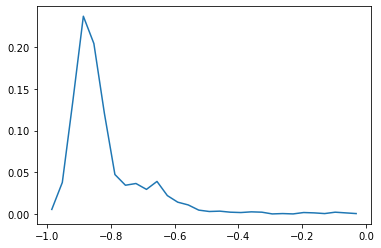

In [13]:
plt.plot(x,y)
plt.show()

In [26]:
# Spline smoothing
spline = UnivariateSpline(x, y, s=0.01)
x_dense = np.linspace(x.min(), x.max(), 500)
y_smooth = spline(x_dense)

# Take only the decreasing part (from peak to end)
peak_idx = np.argmax(y_smooth)
x_decreasing = x_dense[peak_idx+50:]
y_decreasing = y_smooth[peak_idx+50:]

knee = KneeLocator(x_decreasing, y_decreasing, curve='convex', direction='decreasing')


print("Elbow (knee) point:", knee.knee)
print("Y at elbow:", knee.knee_y)

Elbow (knee) point: -0.6021007314629259
Y at elbow: 0.012721665719302206


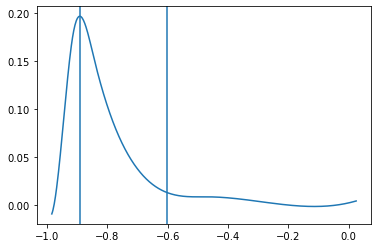

In [27]:
plt.plot(x_dense, y_smooth)
plt.axvline(knee.knee)
plt.axvline(x_dense[peak_idx])
plt.show()

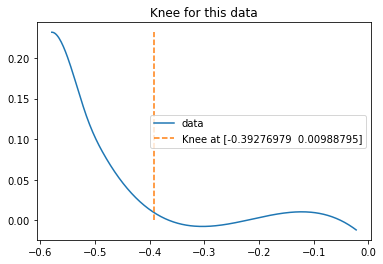

In [52]:
from kneefinder import KneeFinder

spline = UnivariateSpline(x, y, s=0.01)
x_dense = np.linspace(x.min(), x.max(), 500)
y_smooth = spline(x_dense)

peak_idx_max = np.argmax(y_smooth)
peak_idx_min = np.argmin(y_smooth[peak_idx_max:])

x_decreasing = x_dense[peak_idx_max:peak_idx_max+peak_idx_min]
y_decreasing = y_smooth[peak_idx_max:peak_idx_max+peak_idx_min]

kf = KneeFinder(x_decreasing, y_decreasing)

knee_x, knee_y = kf.find_knee()

kf.plot()

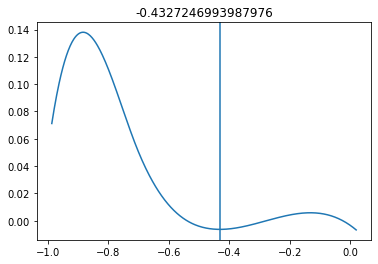

In [61]:
spline = UnivariateSpline(x, y, s=0.01)
x_dense = np.linspace(x.min(), x.max(), 500)
y_smooth = spline(x_dense)

peak_idx_max = np.argmax(y_smooth)
peak_idx_min = np.argmin(y_smooth[peak_idx_max:])

knee = (x_dense[peak_idx_max] + x_dense[peak_idx_max+peak_idx_min])/2
plt.plot(x_dense, y_smooth)
plt.axvline(knee)
plt.title(knee)
plt.show()

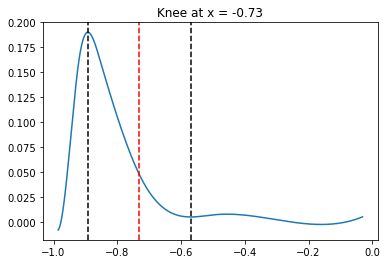

In [14]:
from scipy.interpolate import UnivariateSpline
from scipy.signal import argrelextrema
import numpy as np
import matplotlib.pyplot as plt

# Fit spline
spline = UnivariateSpline(x, y, s=0.01)
x_dense = np.linspace(x.min(), x.max(), 500)
y_smooth = spline(x_dense)

# Find global maximum
peak_idx_max = np.argmax(y_smooth)

# Region after the peak
y_tail = y_smooth[peak_idx_max:]
x_tail = x_dense[peak_idx_max:]

# Try to find local minima
local_min_indices = argrelextrema(y_tail, np.less)[0]

if len(local_min_indices) > 0:
    # Use first local minimum after peak
    min_idx = local_min_indices[0]
else:
    # No local min: fallback to absolute minimum in tail
    min_idx = np.argmin(y_tail)

knee = (x_dense[peak_idx_max] + x_dense[peak_idx_max + min_idx]) / 2
# Plot
plt.plot(x_dense, y_smooth)
plt.axvline(knee, color='red', linestyle='--')
plt.axvline(x_dense[peak_idx_max], color='black', linestyle='--')
plt.axvline(x_dense[peak_idx_max + min_idx], color='black', linestyle='--')
plt.title(f"Knee at x = {knee:.2f}")
plt.show()


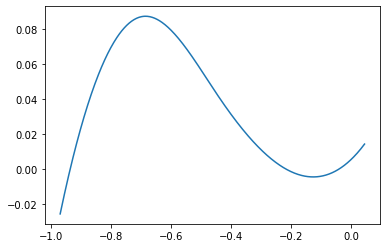

In [56]:
plt.plot(x_dense, y_smooth)
plt.show()

In [3]:
z_df = pd.read_csv('/home/glchang/scratch/Ouroboros/debug/ovarian_1/ouroboros_embeddings_pseudotimes.csv', index_col=0)
meta = pd.read_csv('/projects/steiflab/research/hmacdonald/total_RNA/data/ovarian/ovarian_scratch/ovarian_patient_metadata.csv')

z_df = z_df.merge(test_adata.obs, left_index=True, right_index=True)
z_df = z_df.merge(meta.set_index('patient_id'), how='left', left_on='patient_id', right_index=True)


In [4]:
meta = pd.read_csv('/projects/steiflab/scratch/hmacdonald/vae/ccvae/SHAP/with_PE/riba_mahd_embed/embeddings/hgsoc/HGSOC_embeddings.csv')[['cell_type', "patient_id"]]
z_df = z_df.merge(meta.set_index('patient_id'), how='left', left_on='patient_id', right_index=True)


In [5]:
meta = pd.read_csv('/projects/steiflab/research/hmacdonald/total_RNA/data/ovarian/ovarian_scratch/ovarian_patient_metadata.csv')


In [6]:
z_df

,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,south,dormancy_depth,G0_classification,sample,patient_id,...,total_counts,total_counts_mt,pct_counts_mt,leiden,stress_score_GSEA,Age,Stage,PFI (Days),CRS,cell_type_y
CGAGAAGCATGCAATC-EOC372_iPer,-0.067965,-0.997387,-0.024488,G0,NaN,True,-0.481130,senescence,EOC372_interval_Peritoneum,EOC372,...,3295.0,194.0,5.887709,2,-0.056043,68,IIIC,460,1,EOC
CGAGAAGCATGCAATC-EOC372_iPer,-0.067965,-0.997387,-0.024488,G0,NaN,True,-0.481130,senescence,EOC372_interval_Peritoneum,EOC372,...,3295.0,194.0,5.887709,2,-0.056043,68,IIIC,460,1,EOC
CGAGAAGCATGCAATC-EOC372_iPer,-0.067965,-0.997387,-0.024488,G0,NaN,True,-0.481130,senescence,EOC372_interval_Peritoneum,EOC372,...,3295.0,194.0,5.887709,2,-0.056043,68,IIIC,460,1,EOC
CGAGAAGCATGCAATC-EOC372_iPer,-0.067965,-0.997387,-0.024488,G0,NaN,True,-0.481130,senescence,EOC372_interval_Peritoneum,EOC372,...,3295.0,194.0,5.887709,2,-0.056043,68,IIIC,460,1,EOC
CGAGAAGCATGCAATC-EOC372_iPer,-0.067965,-0.997387,-0.024488,G0,NaN,True,-0.481130,senescence,EOC372_interval_Peritoneum,EOC372,...,3295.0,194.0,5.887709,2,-0.056043,68,IIIC,460,1,EOC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTAAGGATT-EOC443_pOme,-0.919068,-0.075768,-0.386747,G0,NaN,True,-0.420421,senescence,EOC443_primary_Omentum,EOC443,...,1556.0,18.0,1.156812,0,-0.325788,54,IVA,177,3,Immune
TTTGTCAGTAAGGATT-EOC443_pOme,-0.919068,-0.075768,-0.386747,G0,NaN,True,-0.420421,senescence,EOC443_primary_Omentum,EOC443,...,1556.0,18.0,1.156812,0,-0.325788,54,IVA,177,3,Immune
TTTGTCAGTAAGGATT-EOC443_pOme,-0.919068,-0.075768,-0.386747,G0,NaN,True,-0.420421,senescence,EOC443_primary_Omentum,EOC443,...,1556.0,18.0,1.156812,0,-0.325788,54,IVA,177,3,Immune
TTTGTCAGTAAGGATT-EOC443_pOme,-0.919068,-0.075768,-0.386747,G0,NaN,True,-0.420421,senescence,EOC443_primary_Omentum,EOC443,...,1556.0,18.0,1.156812,0,-0.325788,54,IVA,177,3,Immune


In [31]:

eoc = z_df[z_df['cell_type_y'] == 'EOC']
eoc['senescent'] = np.where((eoc['dormancy_depth']<= -0.6), 'Senescent', 'Non-Senescent')
sen_counts = eoc.groupby(['patient_id', 'treatment_phase'])['senescent'].value_counts(normalize=True).unstack().reset_index()
sen_counts = sen_counts.merge(meta, how = 'left', on = 'patient_id')
treat_sen = sen_counts[sen_counts['treatment_phase'] == 'post-NACT']
eoc['quiescent'] = np.where((eoc['dormancy_depth'] >= -0.6), 'Quiescent', 'Non-Quiescent')
qui_counts = eoc.groupby(['patient_id', 'treatment_phase'])['quiescent'].value_counts(normalize=True).unstack().reset_index()
qui_counts = qui_counts.merge(meta, how = 'left', on = 'patient_id')
treat_qui = qui_counts[qui_counts['treatment_phase'] == 'post-NACT']
# Define exact figure size in mm for Inkscape export
width_mm = 70
height_mm = 100
# Convert to inches for matplotlib


/home/glchang/miniconda3/envs/ouroboros_env/lib/python3.6/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/home/glchang/miniconda3/envs/ouroboros_env/lib/python3.6/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Text(0, 0.5, 'Prop. senescent')

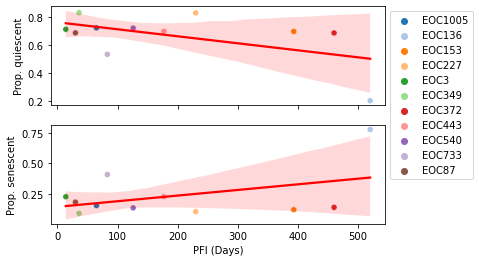

In [32]:
import seaborn as sns
fig, axes = plt.subplots(2, sharex = True)
ax = axes[0]
sns.scatterplot(data = treat_qui, x = 'PFI (Days)', y = 'Quiescent', hue = 'patient_id', ax = ax, palette = 'tab20')
sns.regplot(data = treat_qui, x = 'PFI (Days)', y = 'Quiescent', scatter=False, color='red', ax = ax)
ax.set_ylabel('Prop. quiescent')
ax.legend(bbox_to_anchor = (1,1))
ax = axes[1]
sns.scatterplot(data = treat_sen, x = 'PFI (Days)', y = 'Senescent', hue = 'patient_id', ax = ax, palette = 'tab20', legend = False)
sns.regplot(data = treat_sen, x = 'PFI (Days)', y = 'Senescent', scatter=False, color='red', ax = ax)
ax.set_ylabel('Prop. senescent')

In [6]:
dfs = []
for i in range(1,5):
    curr = pd.read_csv(f'/home/glchang/scratch/Ouroboros/debug/run_jup_{i}/ouroboros_embeddings_pseudotimes.csv')
    curr['library'] = f"Run_{i}"
    dfs.append(curr)

df = pd.concat(dfs)

<AxesSubplot:xlabel='library', ylabel='dormancy_depth'>

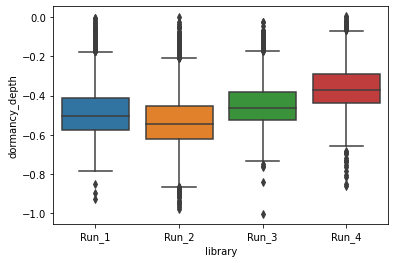

In [7]:
import seaborn as sns
df = df[~df['dormancy_depth'].isna()]
sns.boxplot(data=df, x='library', y='dormancy_depth')

In [73]:
df.groupby('library')['dormancy_depth'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])


,mean,median,std,min,max,count
library,,,,,,
Run_1,-0.532181,-0.545073,0.133144,-0.980559,0.001959,6084
Run_2,-0.532181,-0.545073,0.133144,-0.980559,0.001959,6084
Run_3,-0.532181,-0.545073,0.133144,-0.980559,0.001959,6084
Run_4,-0.532181,-0.545073,0.133144,-0.980559,0.001959,6084
Run_5,-0.532181,-0.545073,0.133144,-0.980559,0.001959,6084


In [2]:
obo.run_ouroboros(
    "/projects/steiflab/scratch/mtong/melanoma/data/processed/filtered_1_1_o.h5ad",
    "h5ad",
    "human",
    '/home/glchang/scratch/Ouroboros/debug/run_jup_1'
)

⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢀⣠⣴⡶⢿⣟⡛⣿⢉⣿⠛⢿⣯⡈⠙⣿⣦⡀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⣠⡾⠻⣧⣬⣿⣿⣿⣿⣿⡟⠉⣠⣾⣿⠿⠿⠿⢿⣿⣦⠀⠀⠀
⠀⠀⠀⠀⣠⣾⡋⣻⣾⣿⣿⣿⠿⠟⠛⠛⠛⠀⢻⣿⡇⢀⣴⡶⡄⠈⠛⠀⠀⠀
⠀⠀⠀⣸⣿⣉⣿⣿⣿⡿⠋⠀⠀⠀⠀⠀⠀⠀⠈⢿⣇⠈⢿⣤⡿⣦⠀⠀⠀⠀
⠀⠀⢰⣿⣉⣿⣿⣿⠏⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⠦⠀⢻⣦⠾⣆⠀⠀⠀
⠀⠀⣾⣏⣿⣿⣿⡟⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⣿⡶⢾⡀⠀⠀
⠀⠀⣿⠉⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣧⣼⡇⠀⠀
⠀⠀⣿⡛⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣿⣧⣼⡇⠀⠀
⠀⠀⠸⡿⢻⣿⣿⣿⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣼⣿⣥⣽⠁⠀⠀
⠀⠀⠀⢻⡟⢙⣿⣿⣿⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⣧⣸⡏⠀⠀⠀
⠀⠀⠀⠀⠻⣿⡋⣻⣿⣿⣿⣦⣤⣀⣀⣀⣀⣀⣠⣴⣿⣿⢿⣥⣼⠟⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠈⠻⣯⣤⣿⠻⣿⣿⣿⣿⣿⣿⣿⣿⣿⠛⣷⣴⡿⠋⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠈⠙⠛⠾⣧⣼⣟⣉⣿⣉⣻⣧⡿⠟⠋⠁⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀Sphere visualization complete⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀


,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,south,dormancy_depth,G0_classification
AAACCTGAGAATGTTG-1,0.515325,0.717615,0.468476,G2M,NaN,True,-0.537433,senescence
AAACCTGAGAGAACAG-1,-0.474633,0.285805,-0.832490,G0,NaN,True,-0.546971,senescence
AAACCTGAGCGTGAGT-1,0.128158,0.393764,-0.910234,G0,NaN,True,-0.560926,senescence
AAACCTGAGGCCCTCA-1,0.148208,0.283935,-0.947320,G0,NaN,True,-0.507663,senescence
AAACCTGAGGCTCATT-1,-0.871047,-0.193922,-0.451299,G1-G0 transition,NaN,True,-0.315158,quiescence
...,...,...,...,...,...,...,...,...
TTTGTCAGTTGTCGCG-1,-0.516484,0.081266,-0.852432,G0,NaN,True,-0.452598,senescence
TTTGTCATCAGCCTAA-1,-0.225706,0.243475,-0.943280,G0,NaN,True,-0.517405,senescence
TTTGTCATCAGTTTGG-1,0.070957,0.484595,-0.871856,G0,NaN,True,-0.611129,senescence
TTTGTCATCCAACCAA-1,-0.812377,0.552080,0.187756,G0,NaN,True,-0.597889,senescence


In [4]:
obo.run_ouroboros(
    "/projects/steiflab/scratch/mtong/melanoma/data/processed/filtered_1_1_o.h5ad",
    "h5ad",
    "human",
    '/home/glchang/scratch/Ouroboros/debug/run_jup_2'
)

⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢀⣠⣴⡶⢿⣟⡛⣿⢉⣿⠛⢿⣯⡈⠙⣿⣦⡀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⣠⡾⠻⣧⣬⣿⣿⣿⣿⣿⡟⠉⣠⣾⣿⠿⠿⠿⢿⣿⣦⠀⠀⠀
⠀⠀⠀⠀⣠⣾⡋⣻⣾⣿⣿⣿⠿⠟⠛⠛⠛⠀⢻⣿⡇⢀⣴⡶⡄⠈⠛⠀⠀⠀
⠀⠀⠀⣸⣿⣉⣿⣿⣿⡿⠋⠀⠀⠀⠀⠀⠀⠀⠈⢿⣇⠈⢿⣤⡿⣦⠀⠀⠀⠀
⠀⠀⢰⣿⣉⣿⣿⣿⠏⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⠦⠀⢻⣦⠾⣆⠀⠀⠀
⠀⠀⣾⣏⣿⣿⣿⡟⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⣿⡶⢾⡀⠀⠀
⠀⠀⣿⠉⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣧⣼⡇⠀⠀
⠀⠀⣿⡛⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣿⣧⣼⡇⠀⠀
⠀⠀⠸⡿⢻⣿⣿⣿⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣼⣿⣥⣽⠁⠀⠀
⠀⠀⠀⢻⡟⢙⣿⣿⣿⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⣧⣸⡏⠀⠀⠀
⠀⠀⠀⠀⠻⣿⡋⣻⣿⣿⣿⣦⣤⣀⣀⣀⣀⣀⣠⣴⣿⣿⢿⣥⣼⠟⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠈⠻⣯⣤⣿⠻⣿⣿⣿⣿⣿⣿⣿⣿⣿⠛⣷⣴⡿⠋⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠈⠙⠛⠾⣧⣼⣟⣉⣿⣉⣻⣧⡿⠟⠋⠁⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀Sphere visualization complete⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀


,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,south,dormancy_depth,G0_classification
AAACCTGAGAATGTTG-1,0.515325,0.717615,0.468476,G2M,NaN,True,-0.537433,senescence
AAACCTGAGAGAACAG-1,-0.474633,0.285805,-0.832490,G0,NaN,True,-0.546971,senescence
AAACCTGAGCGTGAGT-1,0.128158,0.393764,-0.910234,G0,NaN,True,-0.560926,senescence
AAACCTGAGGCCCTCA-1,0.148208,0.283935,-0.947320,G0,NaN,True,-0.507663,senescence
AAACCTGAGGCTCATT-1,-0.871047,-0.193922,-0.451299,G1-G0 transition,NaN,True,-0.315158,quiescence
...,...,...,...,...,...,...,...,...
TTTGTCAGTTGTCGCG-1,-0.516484,0.081266,-0.852432,G0,NaN,True,-0.452598,senescence
TTTGTCATCAGCCTAA-1,-0.225706,0.243475,-0.943280,G0,NaN,True,-0.517405,senescence
TTTGTCATCAGTTTGG-1,0.070957,0.484595,-0.871856,G0,NaN,True,-0.611129,senescence
TTTGTCATCCAACCAA-1,-0.812377,0.552080,0.187756,G0,NaN,True,-0.597889,senescence


In [5]:
obo.run_ouroboros(
    "/projects/steiflab/scratch/mtong/melanoma/data/processed/filtered_1_1_o.h5ad",
    "h5ad",
    "human",
    '/home/glchang/scratch/Ouroboros/debug/run_jup_3'
)

⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢀⣠⣴⡶⢿⣟⡛⣿⢉⣿⠛⢿⣯⡈⠙⣿⣦⡀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⣠⡾⠻⣧⣬⣿⣿⣿⣿⣿⡟⠉⣠⣾⣿⠿⠿⠿⢿⣿⣦⠀⠀⠀
⠀⠀⠀⠀⣠⣾⡋⣻⣾⣿⣿⣿⠿⠟⠛⠛⠛⠀⢻⣿⡇⢀⣴⡶⡄⠈⠛⠀⠀⠀
⠀⠀⠀⣸⣿⣉⣿⣿⣿⡿⠋⠀⠀⠀⠀⠀⠀⠀⠈⢿⣇⠈⢿⣤⡿⣦⠀⠀⠀⠀
⠀⠀⢰⣿⣉⣿⣿⣿⠏⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⠦⠀⢻⣦⠾⣆⠀⠀⠀
⠀⠀⣾⣏⣿⣿⣿⡟⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⣿⡶⢾⡀⠀⠀
⠀⠀⣿⠉⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣧⣼⡇⠀⠀
⠀⠀⣿⡛⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣿⣧⣼⡇⠀⠀
⠀⠀⠸⡿⢻⣿⣿⣿⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣼⣿⣥⣽⠁⠀⠀
⠀⠀⠀⢻⡟⢙⣿⣿⣿⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⣧⣸⡏⠀⠀⠀
⠀⠀⠀⠀⠻⣿⡋⣻⣿⣿⣿⣦⣤⣀⣀⣀⣀⣀⣠⣴⣿⣿⢿⣥⣼⠟⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠈⠻⣯⣤⣿⠻⣿⣿⣿⣿⣿⣿⣿⣿⣿⠛⣷⣴⡿⠋⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠈⠙⠛⠾⣧⣼⣟⣉⣿⣉⣻⣧⡿⠟⠋⠁⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀Sphere visualization complete⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀


,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,south,dormancy_depth,G0_classification
AAACCTGAGAATGTTG-1,0.515325,0.717615,0.468476,G2M,NaN,True,-0.537433,senescence
AAACCTGAGAGAACAG-1,-0.474633,0.285805,-0.832490,G0,NaN,True,-0.546971,senescence
AAACCTGAGCGTGAGT-1,0.128158,0.393764,-0.910234,G0,NaN,True,-0.560926,senescence
AAACCTGAGGCCCTCA-1,0.148208,0.283935,-0.947320,G0,NaN,True,-0.507663,senescence
AAACCTGAGGCTCATT-1,-0.871047,-0.193922,-0.451299,G1-G0 transition,NaN,True,-0.315158,quiescence
...,...,...,...,...,...,...,...,...
TTTGTCAGTTGTCGCG-1,-0.516484,0.081266,-0.852432,G0,NaN,True,-0.452598,senescence
TTTGTCATCAGCCTAA-1,-0.225706,0.243475,-0.943280,G0,NaN,True,-0.517405,senescence
TTTGTCATCAGTTTGG-1,0.070957,0.484595,-0.871856,G0,NaN,True,-0.611129,senescence
TTTGTCATCCAACCAA-1,-0.812377,0.552080,0.187756,G0,NaN,True,-0.597889,senescence


⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢀⣠⣴⡶⢿⣟⡛⣿⢉⣿⠛⢿⣯⡈⠙⣿⣦⡀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⣠⡾⠻⣧⣬⣿⣿⣿⣿⣿⡟⠉⣠⣾⣿⠿⠿⠿⢿⣿⣦⠀⠀⠀
⠀⠀⠀⠀⣠⣾⡋⣻⣾⣿⣿⣿⠿⠟⠛⠛⠛⠀⢻⣿⡇⢀⣴⡶⡄⠈⠛⠀⠀⠀
⠀⠀⠀⣸⣿⣉⣿⣿⣿⡿⠋⠀⠀⠀⠀⠀⠀⠀⠈⢿⣇⠈⢿⣤⡿⣦⠀⠀⠀⠀
⠀⠀⢰⣿⣉⣿⣿⣿⠏⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⠦⠀⢻⣦⠾⣆⠀⠀⠀
⠀⠀⣾⣏⣿⣿⣿⡟⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⣿⡶⢾⡀⠀⠀
⠀⠀⣿⠉⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣧⣼⡇⠀⠀
⠀⠀⣿⡛⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣿⣧⣼⡇⠀⠀
⠀⠀⠸⡿⢻⣿⣿⣿⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣼⣿⣥⣽⠁⠀⠀
⠀⠀⠀⢻⡟⢙⣿⣿⣿⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⣧⣸⡏⠀⠀⠀
⠀⠀⠀⠀⠻⣿⡋⣻⣿⣿⣿⣦⣤⣀⣀⣀⣀⣀⣠⣴⣿⣿⢿⣥⣼⠟⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠈⠻⣯⣤⣿⠻⣿⣿⣿⣿⣿⣿⣿⣿⣿⠛⣷⣴⡿⠋⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠈⠙⠛⠾⣧⣼⣟⣉⣿⣉⣻⣧⡿⠟⠋⠁⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀Sphere visualization complete⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀


,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,south,dormancy_depth,classify
AAACCTGAGAATGTTG-1,0.932748,-0.219596,-0.285935,G1,0.036321,False,NaN,nan
AAACCTGAGAGAACAG-1,-0.653369,0.659655,-0.371435,G0,NaN,True,-0.431182,quiescence
AAACCTGAGCGTGAGT-1,0.128495,0.572483,-0.809785,G1-G0 transition,NaN,True,-0.290812,quiescence
AAACCTGAGGCCCTCA-1,0.052727,0.745892,-0.663977,G1-G0 transition,NaN,True,-0.386513,quiescence
AAACCTGAGGCTCATT-1,-0.976312,-0.133224,-0.170490,G1-G0 transition,NaN,True,-0.226431,quiescence
...,...,...,...,...,...,...,...,...
TTTGTCAGTTGTCGCG-1,-0.811030,0.466830,-0.352561,G1-G0 transition,NaN,True,-0.371429,quiescence
TTTGTCATCAGCCTAA-1,-0.510596,0.593374,-0.622253,G1-G0 transition,NaN,True,-0.340687,quiescence
TTTGTCATCAGTTTGG-1,-0.065325,0.871526,-0.485979,G0,NaN,True,-0.477709,quiescence
TTTGTCATCCAACCAA-1,-0.631708,-0.752467,0.186385,S,0.512596,False,NaN,nan


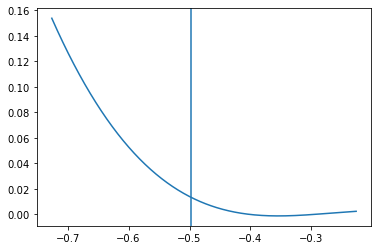

In [4]:
obo.run_ouroboros(
    "/projects/steiflab/scratch/mtong/melanoma/data/processed/filtered_1_1_o.h5ad",
    "h5ad",
    "human",
    '/home/glchang/scratch/Ouroboros/debug/run_jup_4'
)

⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢀⣠⣴⡶⢿⣟⡛⣿⢉⣿⠛⢿⣯⡈⠙⣿⣦⡀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⣠⡾⠻⣧⣬⣿⣿⣿⣿⣿⡟⠉⣠⣾⣿⠿⠿⠿⢿⣿⣦⠀⠀⠀
⠀⠀⠀⠀⣠⣾⡋⣻⣾⣿⣿⣿⠿⠟⠛⠛⠛⠀⢻⣿⡇⢀⣴⡶⡄⠈⠛⠀⠀⠀
⠀⠀⠀⣸⣿⣉⣿⣿⣿⡿⠋⠀⠀⠀⠀⠀⠀⠀⠈⢿⣇⠈⢿⣤⡿⣦⠀⠀⠀⠀
⠀⠀⢰⣿⣉⣿⣿⣿⠏⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⠦⠀⢻⣦⠾⣆⠀⠀⠀
⠀⠀⣾⣏⣿⣿⣿⡟⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⣿⡶⢾⡀⠀⠀
⠀⠀⣿⠉⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣧⣼⡇⠀⠀
⠀⠀⣿⡛⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣿⣧⣼⡇⠀⠀
⠀⠀⠸⡿⢻⣿⣿⣿⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣼⣿⣥⣽⠁⠀⠀
⠀⠀⠀⢻⡟⢙⣿⣿⣿⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⣧⣸⡏⠀⠀⠀
⠀⠀⠀⠀⠻⣿⡋⣻⣿⣿⣿⣦⣤⣀⣀⣀⣀⣀⣠⣴⣿⣿⢿⣥⣼⠟⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠈⠻⣯⣤⣿⠻⣿⣿⣿⣿⣿⣿⣿⣿⣿⠛⣷⣴⡿⠋⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠈⠙⠛⠾⣧⣼⣟⣉⣿⣉⣻⣧⡿⠟⠋⠁⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀Sphere visualization complete⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀


,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,south,dormancy_depth,classify
AAACCTGAGAATGTTG-1,-0.126157,-0.974692,0.184555,G0,NaN,True,-0.765970,senescence
AAACCTGAGAGAACAG-1,-0.542453,-0.727375,0.420323,G0,NaN,True,-0.516423,senescence
AAACCTGAGCGTGAGT-1,-0.035047,-0.810799,0.584275,G0,NaN,True,-0.654700,senescence
AAACCTGAGGCCCTCA-1,-0.204945,-0.598083,0.774786,G0,NaN,True,-0.501567,senescence
AAACCTGAGGCTCATT-1,-0.875151,-0.422602,-0.235624,G1,NaN,True,-0.339735,quiescence
...,...,...,...,...,...,...,...,...
TTTGTCAGTTGTCGCG-1,-0.691146,-0.642400,0.331118,G1-G0 transition,NaN,True,-0.453230,senescence
TTTGTCATCAGCCTAA-1,-0.566496,-0.713716,0.411935,G0,NaN,True,-0.505795,senescence
TTTGTCATCAGTTTGG-1,-0.330263,-0.755460,0.565868,G0,NaN,True,-0.564667,senescence
TTTGTCATCCAACCAA-1,-0.739406,-0.284327,-0.610277,G1,0.564917,False,NaN,nan


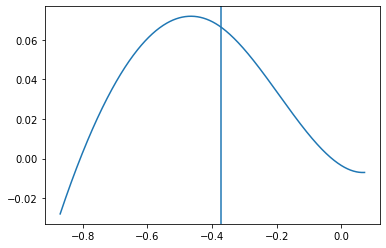

In [8]:
obo.run_ouroboros(
    "/projects/steiflab/scratch/mtong/melanoma/data/processed/filtered_1_1_o.h5ad",
    "h5ad",
    "human",
    '/home/glchang/scratch/Ouroboros/debug/run_jup_5'
)

⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢀⣠⣴⡶⢿⣟⡛⣿⢉⣿⠛⢿⣯⡈⠙⣿⣦⡀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⣠⡾⠻⣧⣬⣿⣿⣿⣿⣿⡟⠉⣠⣾⣿⠿⠿⠿⢿⣿⣦⠀⠀⠀
⠀⠀⠀⠀⣠⣾⡋⣻⣾⣿⣿⣿⠿⠟⠛⠛⠛⠀⢻⣿⡇⢀⣴⡶⡄⠈⠛⠀⠀⠀
⠀⠀⠀⣸⣿⣉⣿⣿⣿⡿⠋⠀⠀⠀⠀⠀⠀⠀⠈⢿⣇⠈⢿⣤⡿⣦⠀⠀⠀⠀
⠀⠀⢰⣿⣉⣿⣿⣿⠏⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⠦⠀⢻⣦⠾⣆⠀⠀⠀
⠀⠀⣾⣏⣿⣿⣿⡟⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⣿⡶⢾⡀⠀⠀
⠀⠀⣿⠉⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣧⣼⡇⠀⠀
⠀⠀⣿⡛⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣿⣧⣼⡇⠀⠀
⠀⠀⠸⡿⢻⣿⣿⣿⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣼⣿⣥⣽⠁⠀⠀
⠀⠀⠀⢻⡟⢙⣿⣿⣿⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⣧⣸⡏⠀⠀⠀
⠀⠀⠀⠀⠻⣿⡋⣻⣿⣿⣿⣦⣤⣀⣀⣀⣀⣀⣠⣴⣿⣿⢿⣥⣼⠟⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠈⠻⣯⣤⣿⠻⣿⣿⣿⣿⣿⣿⣿⣿⣿⠛⣷⣴⡿⠋⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠈⠙⠛⠾⣧⣼⣟⣉⣿⣉⣻⣧⡿⠟⠋⠁⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀Sphere visualization complete⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀


,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,south,dormancy_depth,classify
AAACCTGAGAATGTTG-1,-0.691042,-0.375385,0.617695,G1-G0 transition,NaN,True,-0.165296,quiescence
AAACCTGAGAGAACAG-1,-0.847516,-0.516959,-0.120289,G0,NaN,True,-0.506448,senescence
AAACCTGAGCGTGAGT-1,-0.723704,-0.585279,-0.365652,G0,NaN,True,-0.610246,senescence
AAACCTGAGGCCCTCA-1,-0.442954,-0.892618,-0.083814,G0,NaN,True,-0.450127,senescence
AAACCTGAGGCTCATT-1,-0.923186,0.299840,0.240466,G1,NaN,True,-0.327516,senescence
...,...,...,...,...,...,...,...,...
TTTGTCAGTTGTCGCG-1,-0.937125,-0.346742,-0.039588,G0,NaN,True,-0.475319,senescence
TTTGTCATCAGCCTAA-1,-0.865712,-0.487014,-0.115586,G0,NaN,True,-0.505567,senescence
TTTGTCATCAGTTTGG-1,-0.763924,-0.573807,-0.295239,G0,NaN,True,-0.579971,senescence
TTTGTCATCCAACCAA-1,-0.691068,0.595399,0.409787,G1,0.492068,False,NaN,nan


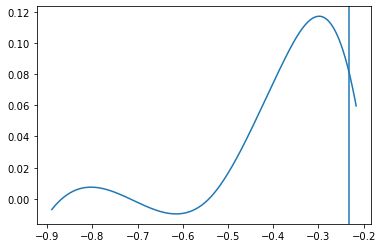

In [9]:
obo.run_ouroboros(
    "/projects/steiflab/scratch/mtong/melanoma/data/processed/filtered_1_1_o.h5ad",
    "h5ad",
    "human",
    '/home/glchang/scratch/Ouroboros/debug/run_jup_5'
)

In [3]:
import anndata as ad
discrete_filtered = ad.read_h5ad("/projects/steiflab/scratch/hmacdonald/total_RNA_scratch/wechter_scratch/starsolo_counts/h5ads/discrete.h5ad")
discrete_filtered

AnnData object with n_obs × n_vars = 2979 × 60649
    obs: 'rep', 'doublet_score', 'doublet_class', 'treatment', 'n_counts', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    layers: 'logged_counts', 'raw_counts', 'scaled_logged_counts', 'spliced', 'unspliced'

In [6]:
discrete_filtered = discrete_filtered[discrete_filtered.obs['treatment'].isin(['IR-induced senescence (10 Gy)', 'Replicative senescence (PDL 57)', 'Etoposide-induced senescent (50 microM)'])]

In [18]:
discrete_filtered.obs = discrete_filtered.obs[['treatment', 'rep']]

In [20]:
discrete_filtered.write_h5ad("/home/glchang/scratch/Ouroboros/ouroboros/data/wechter_discrete.h5ad")

In [23]:
obo.run_ouroboros(
    "/projects/steiflab/scratch/mtong/ovarian_cancer/ovarian_immune_rawcounts.h5ad",
    "h5ad",
    "human",
    '/home/glchang/scratch/Ouroboros/debug/ovarian_1'
)

⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢀⣠⣴⡶⢿⣟⡛⣿⢉⣿⠛⢿⣯⡈⠙⣿⣦⡀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⣠⡾⠻⣧⣬⣿⣿⣿⣿⣿⡟⠉⣠⣾⣿⠿⠿⠿⢿⣿⣦⠀⠀⠀
⠀⠀⠀⠀⣠⣾⡋⣻⣾⣿⣿⣿⠿⠟⠛⠛⠛⠀⢻⣿⡇⢀⣴⡶⡄⠈⠛⠀⠀⠀
⠀⠀⠀⣸⣿⣉⣿⣿⣿⡿⠋⠀⠀⠀⠀⠀⠀⠀⠈⢿⣇⠈⢿⣤⡿⣦⠀⠀⠀⠀
⠀⠀⢰⣿⣉⣿⣿⣿⠏⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⠦⠀⢻⣦⠾⣆⠀⠀⠀
⠀⠀⣾⣏⣿⣿⣿⡟⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⣿⡶⢾⡀⠀⠀
⠀⠀⣿⠉⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣧⣼⡇⠀⠀
⠀⠀⣿⡛⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣿⣧⣼⡇⠀⠀
⠀⠀⠸⡿⢻⣿⣿⣿⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣼⣿⣥⣽⠁⠀⠀
⠀⠀⠀⢻⡟⢙⣿⣿⣿⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⣧⣸⡏⠀⠀⠀
⠀⠀⠀⠀⠻⣿⡋⣻⣿⣿⣿⣦⣤⣀⣀⣀⣀⣀⣠⣴⣿⣿⢿⣥⣼⠟⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠈⠻⣯⣤⣿⠻⣿⣿⣿⣿⣿⣿⣿⣿⣿⠛⣷⣴⡿⠋⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠈⠙⠛⠾⣧⣼⣟⣉⣿⣉⣻⣧⡿⠟⠋⠁⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀Sphere visualization complete⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀


,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,south,dormancy_depth,G0_classification
CGAGAAGCATGCAATC-EOC372_iPer,-0.067965,-0.997387,-0.024488,G0,NaN,True,-0.481130,senescence
AAAGCAAGTTATCGGT-EOC372_pPer,-0.052457,-0.971168,0.232553,G0,NaN,True,-0.560366,senescence
AAAGTAGAGGTCATCT-EOC372_pPer,0.231306,0.965176,-0.122196,S,0.625424,False,NaN,nan
AAATGCCGTTGGTAAA-EOC372_pPer,0.815598,0.542412,0.201467,G2M,0.917335,False,NaN,nan
AACCATGGTGTGCCTG-EOC372_pPer,0.806490,-0.241114,0.539850,G2M,0.992454,False,NaN,nan
...,...,...,...,...,...,...,...,...
TTTGCGCCACATCCAA-EOC443_pOme,-0.372956,-0.742681,-0.556174,G1-G0 transition,NaN,True,-0.350377,senescence
TTTGCGCCACGTCAGC-EOC443_pOme,-0.454212,-0.746155,0.486769,G0,NaN,True,-0.834173,senescence
TTTGCGCCATTCACTT-EOC443_pOme,0.108868,-0.962486,0.248533,G0,NaN,True,-0.495879,senescence
TTTGTCACATTGGGCC-EOC443_pOme,-0.621912,-0.555816,-0.551629,G1-G0 transition,NaN,True,-0.390504,senescence
